# V3 Feature Engineering
### 이상치 clipping + 비율/scale 기반 파생변수 생성

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import StratifiedKFold
import seaborn as sns

In [2]:
DATA_DIR = Path('../Data')
train = pd.read_csv(DATA_DIR / 'train_V2.csv')
test  = pd.read_csv(DATA_DIR / 'test_V2.csv')

print(f"Train: {train.shape}  |  Test: {test.shape}")
print(f"Fraud rate: {train['fraud'].mean():.2%}")

Train: (18000, 93)  |  Test: (12000, 92)
Fraud rate: 15.82%


In [3]:
# Train / Test 합치기 (타겟 컬럼 제외)
train['_is_train'] = 1
test['_is_train']  = 0

# test에는 fraud 컬럼 없음 → 임시 NaN 추가
if 'fraud' not in test.columns:
    test['fraud'] = np.nan

df = pd.concat([train, test], axis=0, ignore_index=True)
print(f"Combined shape: {df.shape}")

Combined shape: (30000, 94)


estimated_residual_value
Skewness (raw) : 1.442
Skewness (log) : -1.066


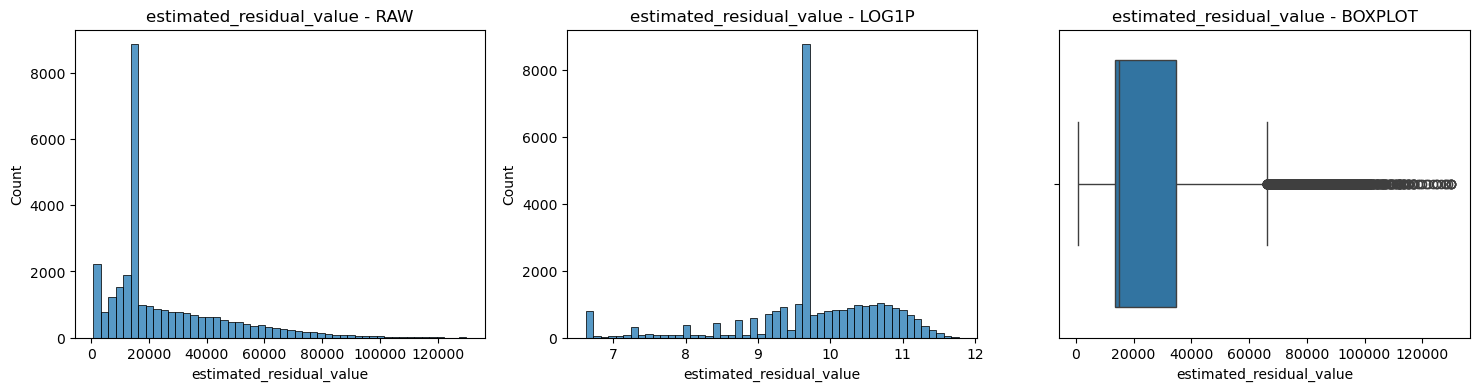

payout_to_income_ratio
Skewness (raw) : 2.559
Skewness (log) : 2.293


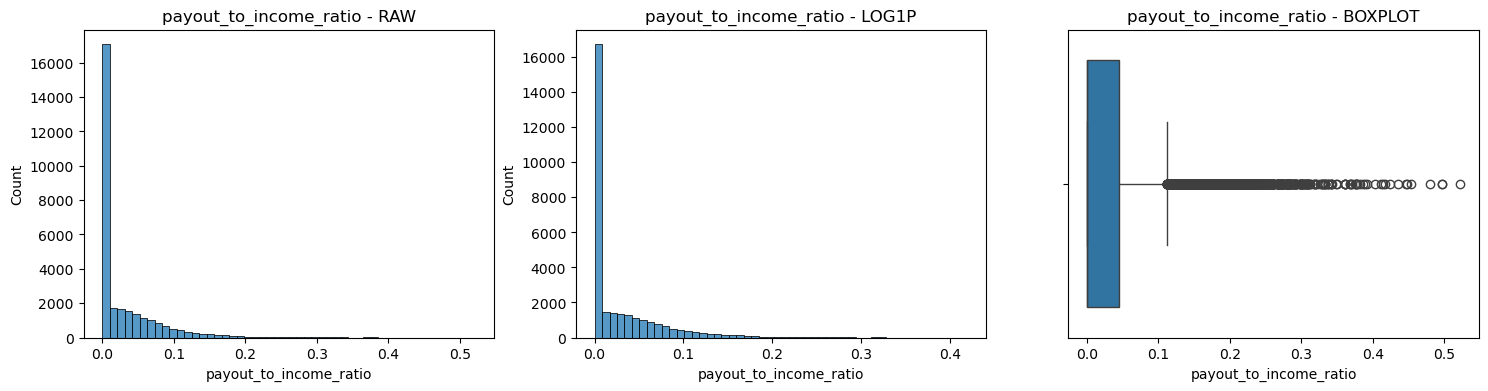

payout_to_price_ratio
Skewness (raw) : 2.301
Skewness (log) : 1.910


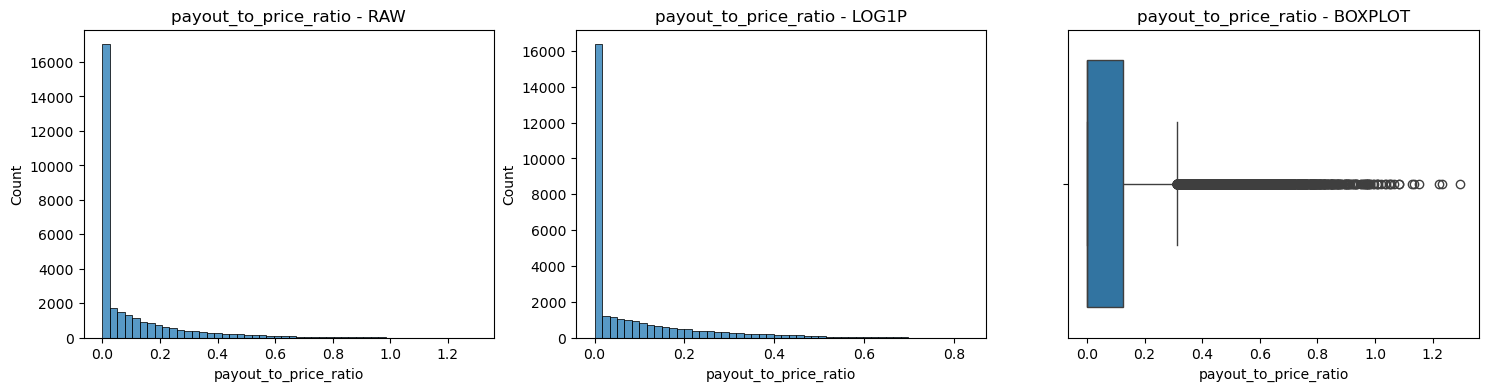

payout_to_residual_ratio
Skewness (raw) : 9.492
Skewness (log) : 4.427


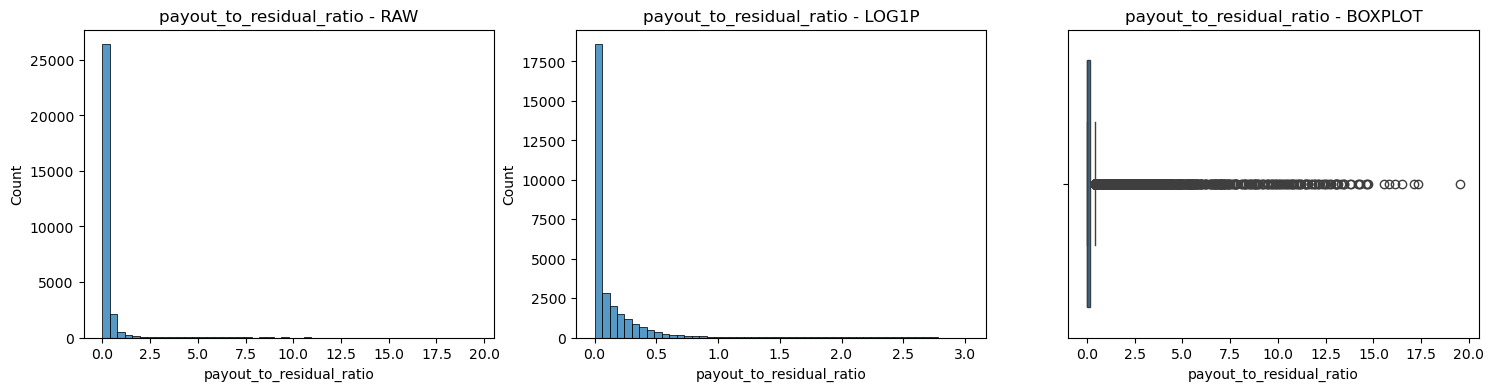

price_per_weight
Skewness (raw) : 3.301
Skewness (log) : 1.039


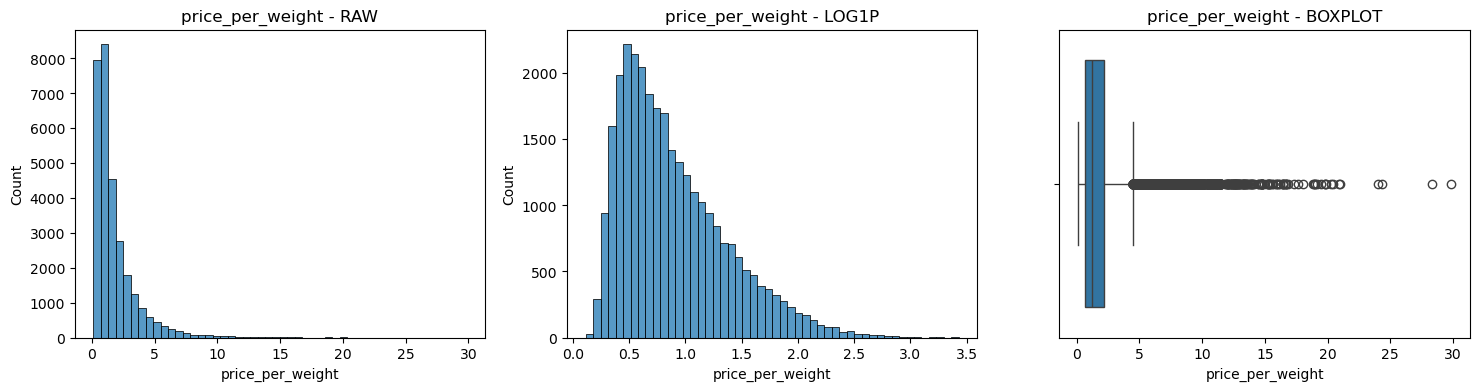

In [4]:
# log화 미처리 피처들 대상
# log화 이후 분포 시각화
cols = [
    "estimated_residual_value",
    "payout_to_income_ratio",
    "payout_to_price_ratio",
    "payout_to_residual_ratio",
    "price_per_weight"
]

for col in cols:
    
    x = df[col].dropna()
    
    print("="*60)
    print(f"{col}")
    print(f"Skewness (raw) : {x.skew():.3f}")
    
    # log transform (safe)
    x_log = np.log1p(x.clip(lower=0))
    
    print(f"Skewness (log) : {x_log.skew():.3f}")
    
    fig, axes = plt.subplots(1,3, figsize=(18,4))
    
    # raw histogram
    sns.histplot(x, bins=50, ax=axes[0])
    axes[0].set_title(f"{col} - RAW")
    
    # log histogram
    sns.histplot(x_log, bins=50, ax=axes[1])
    axes[1].set_title(f"{col} - LOG1P")
    
    # boxplot
    sns.boxplot(x=x, ax=axes[2])
    axes[2].set_title(f"{col} - BOXPLOT")
    
    plt.show()

- 금융 모델에서는 값의 skewness도 신호일 수 있으므로 로그화 진행 X
- 대신 모델 학습 과정의 왜곡 방지를 위해 clipping만 진행

In [5]:
def clip_series(s, q=0.99):
    upper = s.quantile(q)
    return s.clip(upper=upper)

In [6]:
df["payout_to_income_ratio_clipped"] = clip_series(df["payout_to_income_ratio"])
df["payout_to_price_ratio_clipped"] = clip_series(df["payout_to_price_ratio"])
df["payout_to_residual_ratio_clipped"] = clip_series(df["payout_to_residual_ratio"])

In [7]:
EPS = 1e-6

# ==========================
# 1. 추가 ratio / log-ratio
# ==========================

df["residual_to_income_ratio"] = df["estimated_residual_value"] / (df["annual_income"] + EPS)
df["claim_to_weight_ratio"] = df["claim_est_payout"] / (df["vehicle_weight"] + EPS)
df["claim_to_weight_ratio_clipped"] = clip_series(df["claim_to_weight_ratio"])

In [8]:
# ======================================
# 2. 안전/소득/차량 대비 청구의 비정상성
# ======================================
df["payout_per_safety"] = df["claim_est_payout"] / (df["safty_rating"] + EPS)

In [9]:
# ================================
# 3. 운전자/차량/청구 불일치 피처
# ================================
df["vehicle_price_per_driver_age"] = df["vehicle_price"] / (df["age_of_driver"] + EPS)

In [10]:
# ======================================
# 4. 반복청구/검증부재/목격자 부재 조합
# ======================================
df["serial_no_report"] = (
    (df["is_serial_claimer"] == 1) &
    (df["no_police_report"] == 1)
).astype(int)

df["serial_no_witness"] = (
    (df["is_serial_claimer"] == 1) &
    (df["witness_absent"] == 1)
).astype(int)

df["repeat_claim_full_liability"] = (
    (df["is_repeat_claimer"] == 1) &
    (df["full_liability_flag"] == 1)
).astype(int)

df["no_witness_no_report_full_liability"] = (
    (df["witness_absent"] == 1) &
    (df["no_police_report"] == 1) &
    (df["full_liability_flag"] == 1)
).astype(int)

In [11]:
# ==========================================
# 5. clipped / log ratio 기반 extreme flag
# ==========================================
for col in [
    "payout_to_income_ratio_clipped",
    "payout_to_price_ratio_clipped",
    "payout_to_residual_ratio_clipped"
]:
    q95 = df[col].quantile(0.95)
    q99 = df[col].quantile(0.99)

    df[f"{col}_top5_flag"] = (df[col] >= q95).astype(int)
    df[f"{col}_top1_flag"] = (df[col] >= q99).astype(int)

# 로그 ratio extreme 조합
df["high_income_ratio_and_no_report"] = (
    (df["payout_to_income_ratio_clipped_top5_flag"] == 1) &
    (df["no_police_report"] == 1)
).astype(int)

df["high_residual_ratio_and_repeat"] = (
    (df["payout_to_residual_ratio_clipped_top5_flag"] == 1) &
    (df["is_repeat_claimer"] == 1)
).astype(int)

In [12]:
# ===================
# 7. risk score 조합
# ===================
df["composite_x_income_ratio"] = df["composite_risk_score"] * (1 + df["payout_to_income_ratio_clipped"])

In [13]:
# =====================
# 8. binning 기반 피처
# =====================
df["income_bin"] = pd.qcut(
    df["annual_income"],
    q=5,
    labels=False,
    duplicates="drop"
)

df["claim_bin"] = pd.qcut(
    df["claim_est_payout"],
    q=5,
    labels=False,
    duplicates="drop"
)

df["income_claim_bin_gap"] = df["claim_bin"] - df["income_bin"]

In [14]:
# Train / Test 재분리
train_fe = df[df['_is_train'] == 1].drop(columns=['_is_train']).copy()
test_fe  = df[df['_is_train'] == 0].drop(columns=['_is_train', 'fraud']).copy()

print(f"Train 피처 엔지니어링 완료: {train_fe.shape}")
print(f"Test  피처 엔지니어링 완료: {test_fe.shape}")

Train 피처 엔지니어링 완료: (18000, 117)
Test  피처 엔지니어링 완료: (12000, 116)


In [15]:
# 최종 데이터셋 저장
X_train = train_fe.drop(columns=['fraud']).copy()
y_train = train_fe['fraud']
X_test  = test_fe

print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}  (fraud={y_train.mean():.2%})")
print(f"X_test:  {X_test.shape}")

# CSV 저장 (V3 데이터셋)
X_train.assign(fraud=y_train.values).to_csv(DATA_DIR / 'train_V3.csv', index=False)
X_test.to_csv(DATA_DIR / 'test_V3.csv', index=False)

X_train: (18000, 116)
y_train: (18000,)  (fraud=15.82%)
X_test:  (12000, 116)
